In [2]:

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from task1.classifier import MnistClassifier

In [ ]:
import gradio as gr
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageEnhance

rf_clf = MnistClassifier(algorithm='rf')
rf_clf.load("../weights/rf_model.joblib")

ffnn_clf = MnistClassifier(algorithm='ffnn')
ffnn_clf.load("../weights/ffnn_model.pth")

cnn_clf = MnistClassifier(algorithm='cnn')
cnn_clf.load("../weights/cnn_model.pth")


from pathlib import Path
import time

def predict_digit(image):
    if image is None: 
        return "Draw some digit", None
    
    img = Image.fromarray(image["composite"]).convert('RGBA')
    bg = Image.new('RGBA', img.size, (255, 255, 255))
    combined = Image.alpha_composite(bg, img).convert('L')
    inverted_img = ImageOps.invert(combined)
    processed_img = inverted_img.resize((28, 28), Image.Resampling.LANCZOS)
    processed_img = processed_img.point(lambda p: p * 1.5 if p > 50 else 0)

    debug_dir = Path("debug_inputs")
    debug_dir.mkdir(exist_ok=True)
  
    save_path = debug_dir / "last_input.png"
    processed_img.save(save_path)
    
    img_array = np.array(processed_img).astype('float32') / 255.0
    input_data = img_array[None, ...]

    rf_res = rf_clf.predict(input_data)[0]
    ffnn_res = ffnn_clf.predict(input_data)[0]
    cnn_res = cnn_clf.predict(input_data)[0]

    return f"RF: {rf_res}; FFNN: {ffnn_res}; CNN: {cnn_res}"

interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Sketchpad(label="Draw a digit here", type="numpy"),
    outputs=gr.Textbox(label="Model Predictions"),
    title="MNIST Digit Classifiers",
    live=True
)

interface.launch()

c:\Users\Andrew\Documents\test-assignment\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Weights loaded from ../weights/ffnn_model.pth
Weights loaded from ../weights/cnn_model.pth
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [6]:
from utils.data_loader import get_mnist_dataset
X_train, X_test, y_train, y_test = get_mnist_dataset()

print(f"Dataset loaded. Test set size: {X_test.shape[0]} samples.")

Dataset loaded. Test set size: 14000 samples.



 Analyzing Model: Random Forest


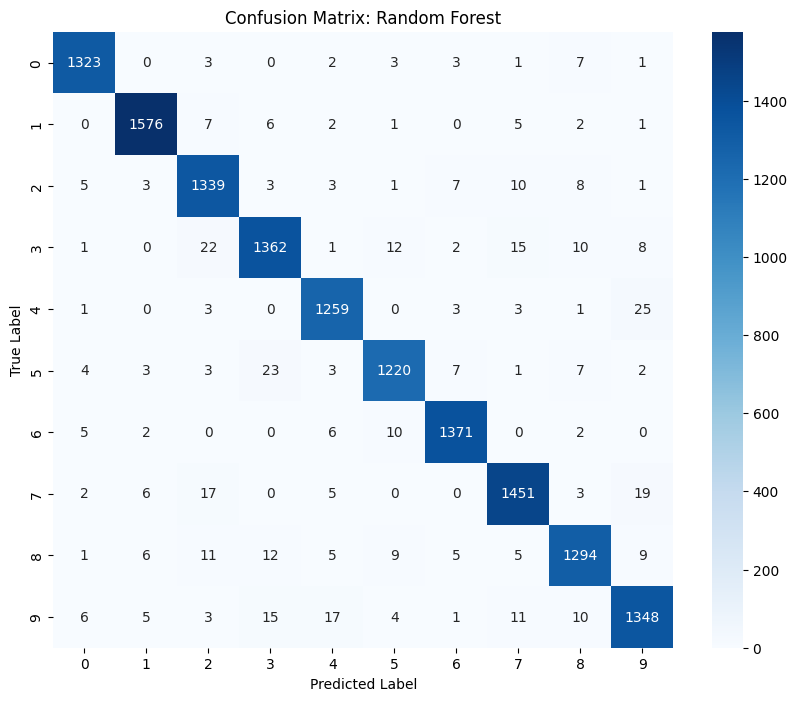


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1343
           1       0.98      0.98      0.98      1600
           2       0.95      0.97      0.96      1380
           3       0.96      0.95      0.95      1433
           4       0.97      0.97      0.97      1295
           5       0.97      0.96      0.96      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.96      0.95      0.96      1357
           9       0.95      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000


 Analyzing Model: FFNN


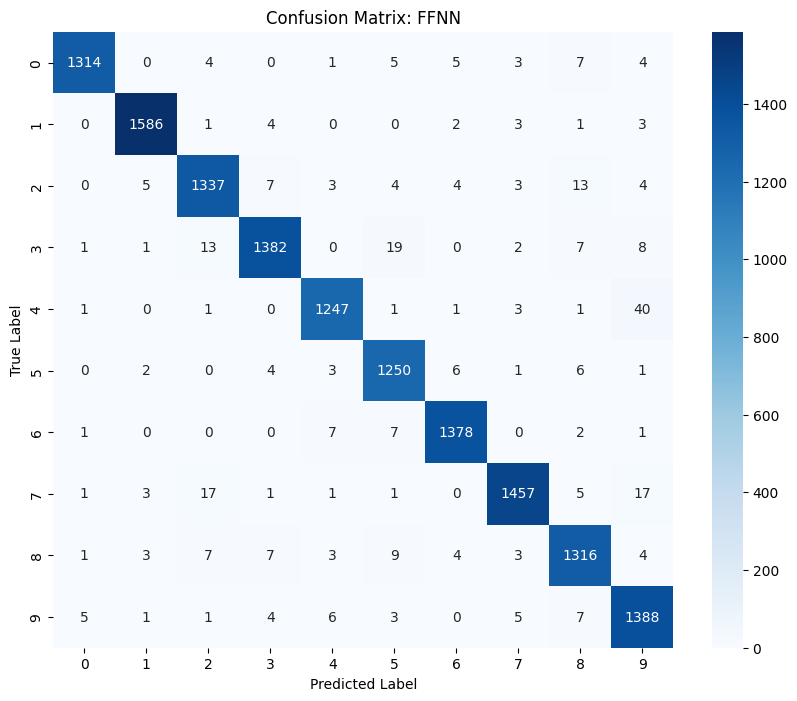


Classification Report for FFNN:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.97      0.97      0.97      1380
           3       0.98      0.96      0.97      1433
           4       0.98      0.96      0.97      1295
           5       0.96      0.98      0.97      1273
           6       0.98      0.99      0.99      1396
           7       0.98      0.97      0.98      1503
           8       0.96      0.97      0.97      1357
           9       0.94      0.98      0.96      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000


 Analyzing Model: CNN


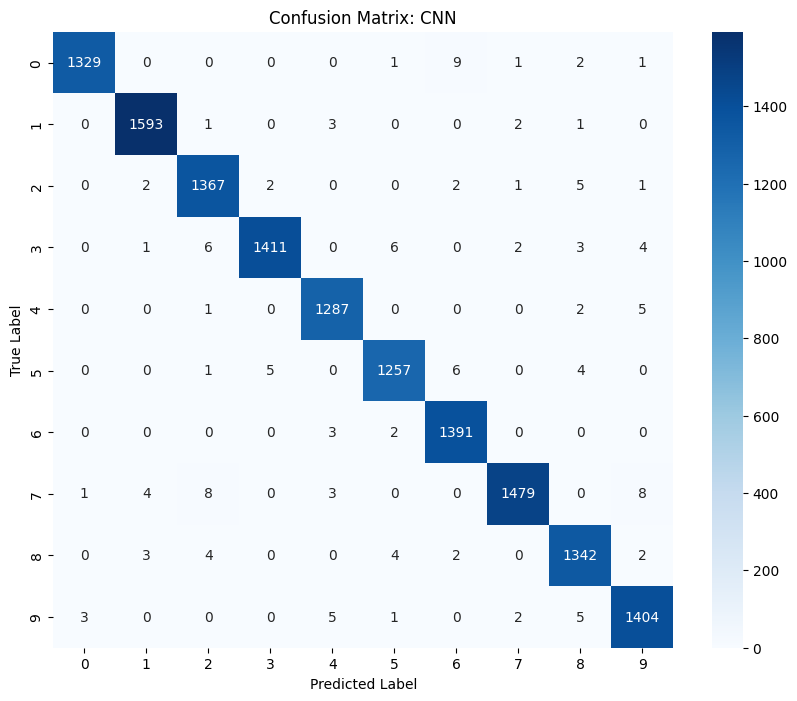


Classification Report for CNN:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1343
           1       0.99      1.00      0.99      1600
           2       0.98      0.99      0.99      1380
           3       1.00      0.98      0.99      1433
           4       0.99      0.99      0.99      1295
           5       0.99      0.99      0.99      1273
           6       0.99      1.00      0.99      1396
           7       0.99      0.98      0.99      1503
           8       0.98      0.99      0.99      1357
           9       0.99      0.99      0.99      1420

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model_performance(model, name, x_test, y_test):

    print(f"\n Analyzing Model: {name}")
    
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(10), yticklabels=range(10))
    
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))

evaluate_model_performance(rf_clf, "Random Forest", X_test, y_test)
evaluate_model_performance(ffnn_clf, "FFNN", X_test, y_test)
evaluate_model_performance(cnn_clf, "CNN", X_test, y_test)